In [39]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import pandas as pd
import ast
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any
from obspy.signal.filter import envelope
from enveloc.core import XCOR
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
import numpy as np
from obspy import Stream
import matplotlib.pyplot as plt


from obspy import Stream
import numpy as np
from scipy.signal import hilbert
import os

import pandas as pd
import ast
from obspy import UTCDateTime
from obspy.core.event import (
    Catalog, Event, Origin, Comment,
    CreationInfo, ResourceIdentifier
)

In [32]:
client = Client("IRIS")

# Mount Rainier-ish bounding box (adjust)
minlat, maxlat = 46, 49
minlon, maxlon = -123, -120


def drop_stations_with_gaps(st: Stream, max_total_gap_s=0.0) -> Stream:
    """
    For each NET.STA.LOC.CHA:
      - merge fragments
      - if total gap > max_total_gap_s -> drop that id entirely
      - else keep the merged trace
    """
    out = Stream()

    # group by full trace id
    for tr_id in sorted(set(tr.id for tr in st)):
        s = st.select(id=tr_id).copy()
        if len(s) == 0:
            continue

        # quantify gaps BEFORE merge (merge doesn't magically create data)
        gaps = s.get_gaps()  # list of gap tuples
        total_gap = sum(float(g[6]) for g in gaps) if gaps else 0.0

        if total_gap > max_total_gap_s:
            # drop this station/channel (e.g., UW.STAR.01.EHZ)
            continue

        # no gaps -> safe to merge fragments into one trace
        s.merge(method=1)
        out += s[0]

    return out



def resolve_net_loc_chan(station, t_start, t_end):
    inv = client.get_stations(
        network="*",
        station=station,
        channel="*HZ",          # or BHZ/HHZ/EHZ later
        starttime=t_start,
        endtime=t_end,
        minlatitude=minlat, maxlatitude=maxlat,
        minlongitude=minlon, maxlongitude=maxlon,
        level="channel",
    )

    # Pick the first matching channel entry (you can make this smarter)
    for net in inv:
        for sta in net:
            for cha in sta:
                return net.code, sta.code, cha.location_code, cha.code

    return None  # nothing matched in region


def resolve_net_loc_chan(
    station, t_start, t_end,
    loc_preference=("01", "", "--"),     # "" usually corresponds to "--"
    chan_hint="*HZ",
):
    inv = client.get_stations(
        network="*",
        station=station,
        channel=chan_hint,               # keep broad here; we’ll still prefer BHZ/HHZ/EHZ later
        starttime=t_start,
        endtime=t_end,
        minlatitude=minlat, maxlatitude=maxlat,
        minlongitude=minlon, maxlongitude=maxlon,
        level="channel",
    )

    candidates = []
    for net in inv:
        for sta in net:
            for cha in sta:
                loc = cha.location_code or ""  # normalize None -> ""
                candidates.append((net.code, sta.code, loc, cha.code))

    if not candidates:
        return None

    # Keep only candidates whose loc is in our preference list
    preferred = [c for c in candidates if c[2] in loc_preference]
    pool = preferred if preferred else candidates  # fallback if none match

    # Choose by: (loc preference order) then (keep deterministic by chan code)
    loc_rank = {loc: i for i, loc in enumerate(loc_preference)}
    pool.sort(key=lambda x: (loc_rank.get(x[2], 999), x[3]))
    return pool[0]  # (net, sta, loc, chan)




def download_best_vertical(station, t_start, t_end):
    resolved = resolve_net_loc_chan(station, t_start, t_end)
    if resolved is None:
        print(f"[{station}] not found in region/time window")
        return Stream()

    net, sta, loc, _ = resolved

    # Prefer BHZ -> HHZ -> EHZ, using the resolved network + location
    for ch in ("BHZ", "HHZ", "EHZ"):
        try:
            st = client.get_waveforms(net, sta, loc, ch, t_start, t_end)
            if len(st) > 0:
                print(f"Downloaded {net}.{sta}.{loc}.{ch}")
                return st
        except Exception:
            pass

    print(f"[{station}] no BHZ/HHZ/EHZ for {net}.{sta}.{loc} in window")
    return Stream()





def download_station_data(row, seconds_before= 0, seconds_after= 200, network='*', client_name='IRIS'):
    """
    Downloads vertical component seismic data for all stations in a dataframe row.
    
    Parameters:
    -----------
    row : pandas.Series
        A row from your dataframe containing 'rounded_start' and 'stations' columns
    seconds_before : int
        Seconds to download before rounded_start time (default: 30)
    seconds_after : int
        Seconds to download after rounded_start time (default: 60)
    network : str
        Network code (default: '*' for all networks)
    client_name : str
        FDSN client to use (default: 'IRIS')
    
    Returns:
    --------
    stream : obspy.Stream
        Stream object containing all downloaded traces
    """
    
    
    # Initialize client
    client = Client(client_name)
    
    start_time = UTCDateTime(pd.Timestamp(row['rounded_start']).to_pydatetime())
    
    # Calculate time window
    t_start = start_time - seconds_before
    t_end = start_time + seconds_after
    
    # Initialize empty stream
    stream = Stream()
    
    # Get list of stations
    s = row['stations']
    stations = tuple(ast.literal_eval(s))
    
    # Download data for each station
    
    stream = Stream()
    for station in stations:
        stream += download_best_vertical(station, t_start, t_end)

    return stream
    
    

# Example usage:
# Apply to entire dataframe
def process_dataframe(df, seconds_before=30, seconds_after=60):
    """
    Process entire dataframe and return dictionary of streams.
    """
    streams = {}
    
    for idx, row in df.iterrows():
        print(f"\nProcessing row {idx}...")
        stream = download_station_data(row, seconds_before, seconds_after)
        streams[idx] = stream
        print(f"Total traces downloaded: {len(stream)}")
    
    return streams

# Usage:
# streams_dict = process_dataframe(df, seconds_before=30, seconds_after=60)
# 
# # Access individual stream
# first_stream = streams_dict[0]
# 
# # Or process single row
# single_stream = download_station_data(df.iloc[0], seconds_before=30, seconds_after=60)



def plot_waveforms_and_envelopes(st_filt, st_env, title=None, max_traces=None):
    """
    Stacked plot with uniform spacing and envelopes overlaid.
    - Each waveform normalized by max(|waveform|)
    - Each envelope normalized by max(|envelope|)
    - Uniform spacing of 1 between traces
    - Envelope plotted as thicker black line on top of waveform
    """

    # Sort for consistent ordering
    st_filt = st_filt.copy().sort(keys=["network", "station", "channel", "location"])
    st_env  = st_env.copy().sort(keys=["network", "station", "channel", "location"])

    if max_traces is not None:
        st_filt = st_filt[:max_traces]

    # Map envelopes by NET.STA.CHA for alignment
    env_by_id = {
        f"{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}": tr
        for tr in st_env
    }

    n = len(st_filt)
    fig, ax = plt.subplots(1, 1, figsize=(8, 0.6 * n + 3))

    ytick_pos, ytick_lab = [], []

    for i, tr in enumerate(st_filt):
        key = f"{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}"
        if key not in env_by_id:
            continue

        tr_env = env_by_id[key]

        # Time axes
        t_w = np.arange(tr.stats.npts) / tr.stats.sampling_rate
        t_e = np.arange(tr_env.stats.npts) / tr_env.stats.sampling_rate

        # Data
        y_w = tr.data.astype(np.float64)
        y_e = tr_env.data.astype(np.float64)

        # Normalize by max abs
        wmax = np.max(np.abs(y_w))
        emax = np.max(np.abs(y_e))
        if wmax == 0 or not np.isfinite(wmax):
            wmax = 1.0
        if emax == 0 or not np.isfinite(emax):
            emax = 1.0

        y_w = y_w / wmax
        y_e = y_e / emax

        # Interpolate envelope onto waveform time axis for clean overlay
        y_e_interp = np.interp(t_w, t_e, y_e, left=np.nan, right=np.nan)

        # Uniform spacing of 1 between traces
        offset = (n - 1 - i) * 1.0

        # Plot waveform (thin)
        ax.plot(t_w, y_w + offset, linewidth=0.8)

        # Plot envelope (thicker black line)
        ax.plot(t_w, y_e_interp + offset, linewidth=2.0, color="black")

        ytick_pos.append(offset)
        ytick_lab.append(key)

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_lab, fontsize=9)
    ax.set_xlabel("Time (s) from trace start")
    ax.grid(True, alpha=0.2)

    if title:
        ax.set_title(title)
    else:
        ax.set_title("Waveforms (normalized) with envelopes (thick black) overlaid")

    plt.tight_layout()
    plt.show()
    
    
    

from obspy import Stream
import numpy as np
from scipy.signal import hilbert


def robust_envelope_snr(tr, q=0.99, eps=1e-12):
    """
    Robust SNR using:
        SNR = quantile(env, q) / median(env)

    where env = abs(hilbert(trace))
    """
    x = np.asarray(tr.data, dtype=float)

    if x.size == 0:
        return np.nan

    # Clean bad values
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    # Envelope
    env = np.abs(hilbert(x))

    median_env = np.median(env)
    if (not np.isfinite(median_env)) or median_env < eps:
        return np.nan

    peak_env = np.quantile(env, q)

    return float(peak_env / median_env)


def filter_low_snr_traces(st, snr_threshold= 5.0, q=0.99, verbose=True):
    """
    Remove traces whose robust envelope SNR < threshold.

    Returns:
        st_filtered
        snr_dict (trace.id -> snr)
    """

    snr_dict = {}
    keep = []

    for tr in st:
        snr = robust_envelope_snr(tr, q=q)
        snr_dict[tr.id] = snr

        if np.isfinite(snr) and snr >= snr_threshold:
            keep.append(tr)

    st_filtered = Stream(keep)

    if verbose:
        print(f"Original traces: {len(st)}")
        print(f"Kept traces: {len(st_filtered)}")
        print(f"Dropped traces: {len(st) - len(st_filtered)}")

    return st_filtered, snr_dict

In [33]:
su_events = pd.read_csv('../logs/surface_event_detections_1_17_december_2025.csv')



In [34]:
su_events

,Unnamed: 0,cluster_id,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob
0,14,48,2025-12-01 00:54:30+00:00,4,"['BHW', 'GNOB', 'JCW', 'OBSR']","['su', 'su', 'su', 'su']",su,25.778360,0.748348,0.410378
1,40,152,2025-12-01 02:53:30.009998+00:00,4,"['MILD', 'OBSR', 'RCM', 'RCS']","['su', 'su', 'su', 'su']",su,5.845405,0.778858,0.414012
2,41,153,2025-12-01 02:54:10+00:00,5,"['LTY', 'PANH', 'PARA', 'RER', 'TBLMT']","['su', 'su', 'su', 'su', 'su']",su,5.351200,0.794211,0.455832
3,89,369,2025-12-01 06:47:40+00:00,10,"['ARAT', 'COPP', 'FMW', 'MILD', 'OBSR', 'PANH'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,8.337438,0.953159,0.595827
4,105,432,2025-12-01 07:57:40+00:00,11,"['ARAT', 'COPP', 'LO2', 'MILD', 'OBSR', 'PANH'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.456046,0.793113,0.479240
...,...,...,...,...,...,...,...,...,...,...
181,3721,22579,2025-12-16 17:19:04.080000+00:00,4,"['COPP', 'MILD', 'NAC2', 'RCM']","['su', 'su', 'su', 'su']",su,3.737965,0.593753,0.351201
182,3795,22877,2025-12-16 21:58:04.760000+00:00,5,"['BHW', 'GNOB', 'LONR', 'LTY', 'VOIT']","['su', 'su', 'su', 'su', 'su']",su,8.449714,0.638644,0.407500
183,3842,23119,2025-12-17 01:35:25.680000+00:00,4,"['GNOB', 'LTY', 'SHUK', 'VOIT']","['su', 'su', 'su', 'su']",su,23.795972,0.796823,0.470042
184,3899,23375,2025-12-17 05:43:39.996000+00:00,4,"['LONR', 'RER', 'SHUK', 'VOIT']","['su', 'su', 'su', 'su']",su,12.919095,0.721894,0.444830


Downloaded CC.ARAT..BHZ
Downloaded CC.COPP..BHZ
Downloaded UW.LO2..EHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.RCS..EHZ
Downloaded UW.RER..HHZ
Downloaded UW.STAR.01.EHZ
Original traces: 10
Kept traces: 7
Dropped traces: 3


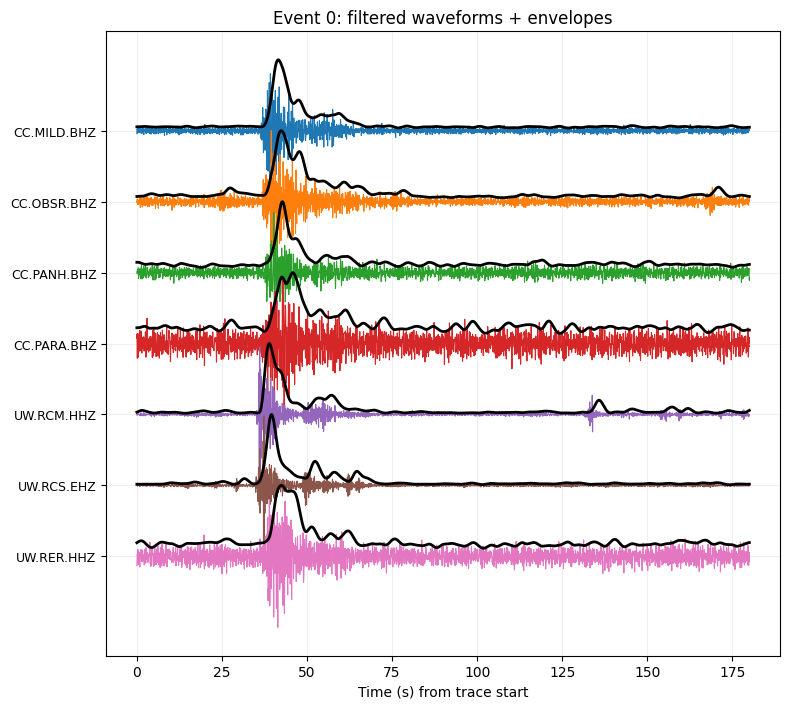

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.01 07:57:50  --  2025.12.01 08:00:50
--Location--
Latitude: 46.858, Longitude: -121.743, Depth: 0.0 km


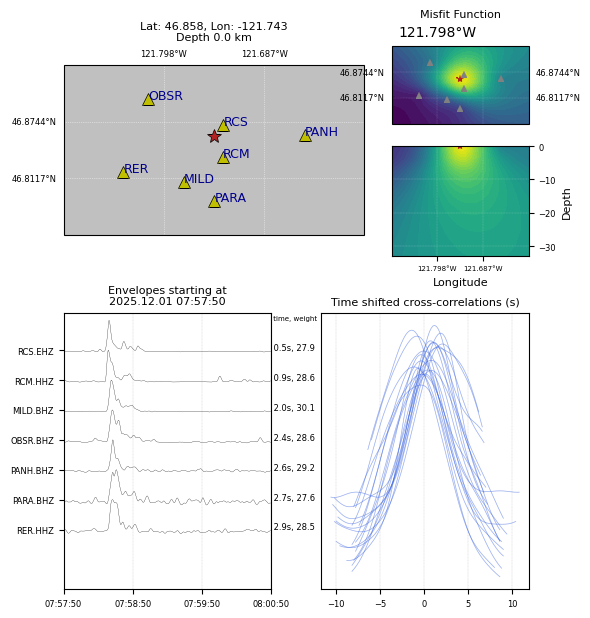

-121.742546 46.85792538
Saved map to: ../plotly_map_locations/2025-12-01_07-57-40+00-00.html


Downloaded CC.ARAT..BHZ
Downloaded CC.COPP..BHZ
Downloaded UW.FMW..HHZ
Downloaded UW.LO2..EHZ
Downloaded UW.LON..HHZ
Downloaded CC.LONR..BHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
[PALI] no BHZ/HHZ/EHZ for C0.PALI. in window
Downloaded CC.PARA..BHZ
Downloaded CC.PR05..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.RER..HHZ
Downloaded CC.RUSH..BHZ
Downloaded CC.SIFT..BHZ
Downloaded UW.STAR.01.EHZ
Downloaded CC.SUNT..HHZ
Downloaded CC.TABR..BHZ
Downloaded CC.TAVI..BHZ
Original traces: 18
Kept traces: 15
Dropped traces: 3


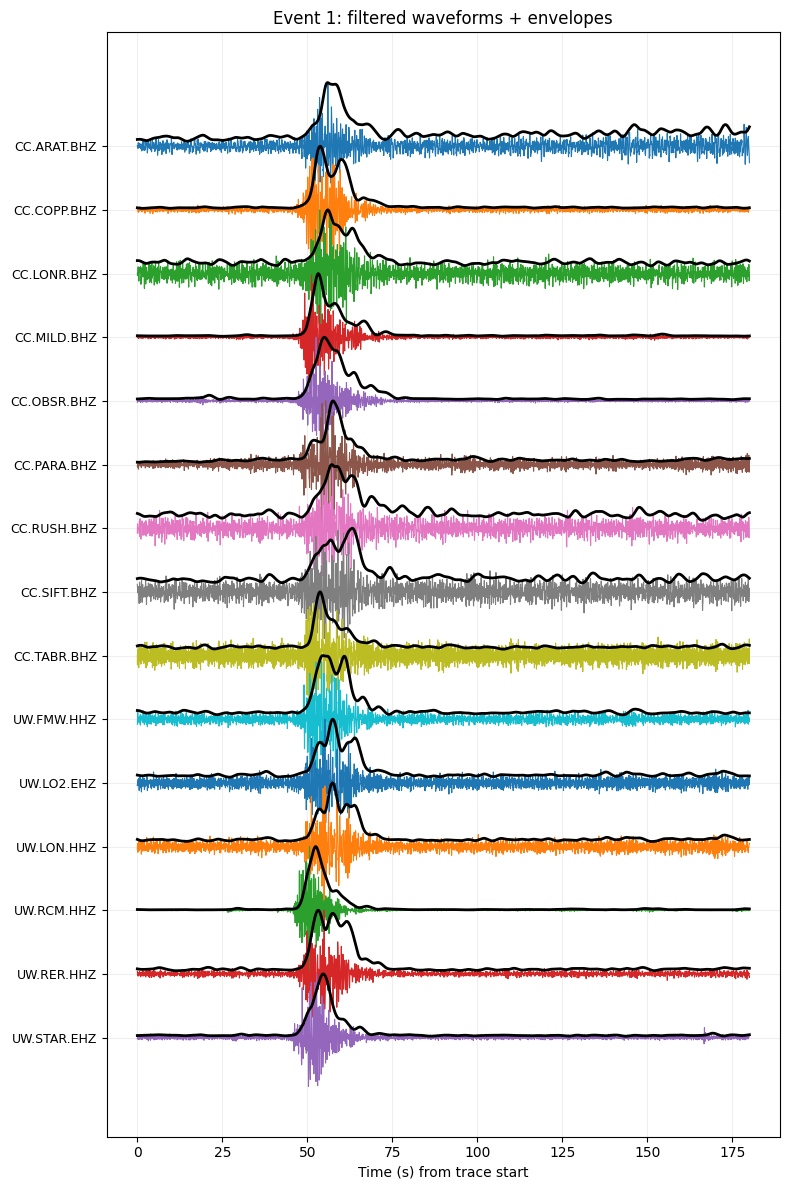

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.01 23:17:30  --  2025.12.01 23:20:30
--Location--
Latitude: 46.869, Longitude: -121.734, Depth: 0.0 km


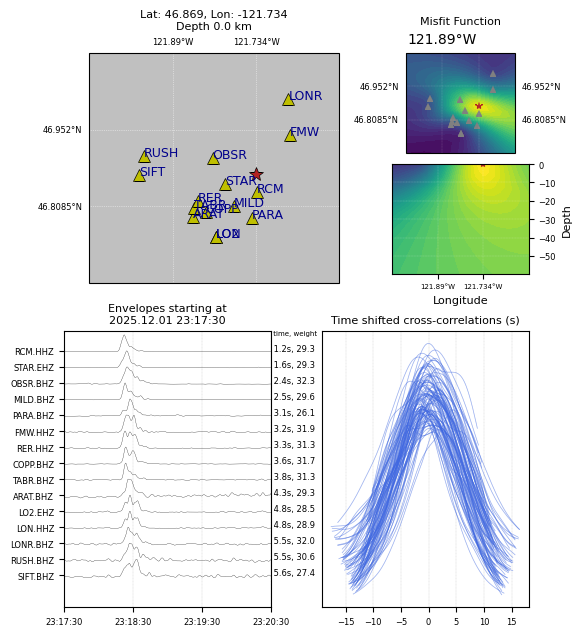

-121.73440591666666 46.86891757736842
Saved map to: ../plotly_map_locations/2025-12-01_23-17-20+00-00.html


Downloaded UW.BHW..HHZ
Downloaded CC.COPP..BHZ
Downloaded UW.FMW..HHZ
Downloaded UW.GPW..HHZ
Downloaded UW.JCW..EHZ
Downloaded UW.LON..HHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.STAR.01.EHZ
Original traces: 12
Kept traces: 8
Dropped traces: 4


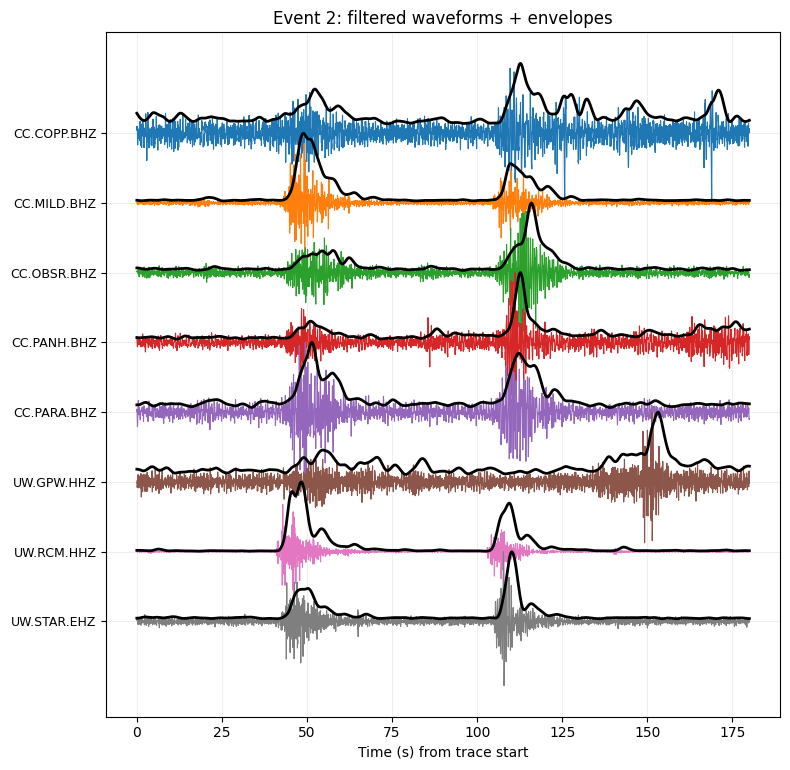

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.02 13:24:40  --  2025.12.02 13:27:40
--Location--
Latitude: 46.812, Longitude: -121.722, Depth: 0.0 km


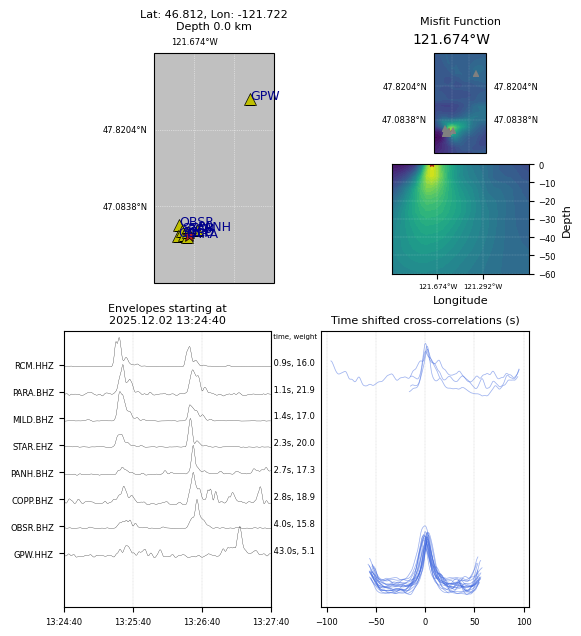

-121.72226245833333 46.81236551736843
Saved map to: ../plotly_map_locations/2025-12-02_13-24-30+00-00.html


Downloaded CC.ARAT..BHZ
Downloaded CC.COPP..BHZ
Downloaded UW.FMW..HHZ
Downloaded UW.LO2..EHZ
Downloaded UW.LON..HHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.RER..HHZ
Downloaded UW.STAR.01.EHZ
Original traces: 12
Kept traces: 8
Dropped traces: 4


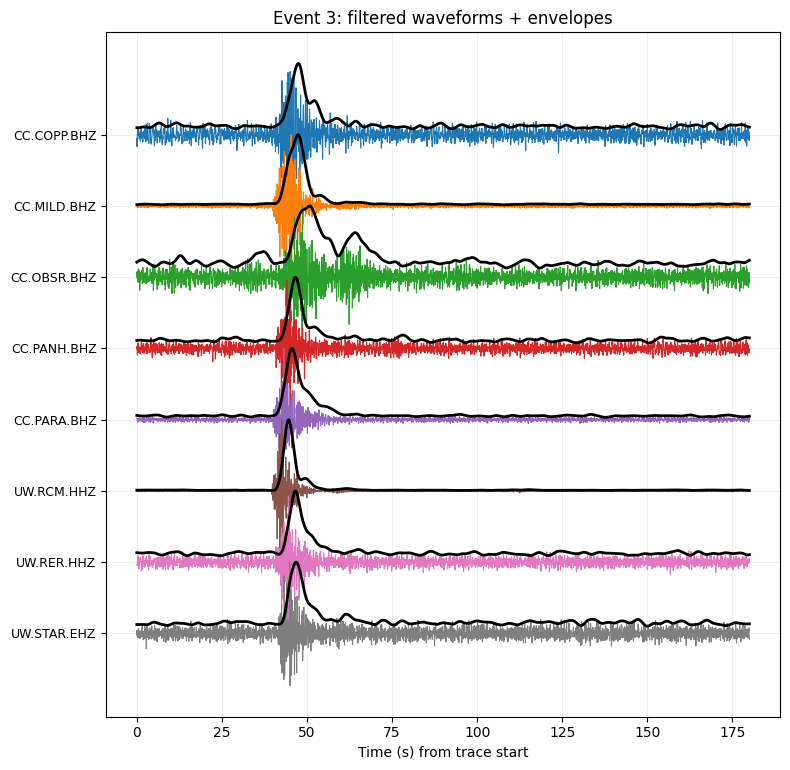

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.03 12:41:10  --  2025.12.03 12:44:10
--Location--
Latitude: 46.818, Longitude: -121.715, Depth: 0.0 km


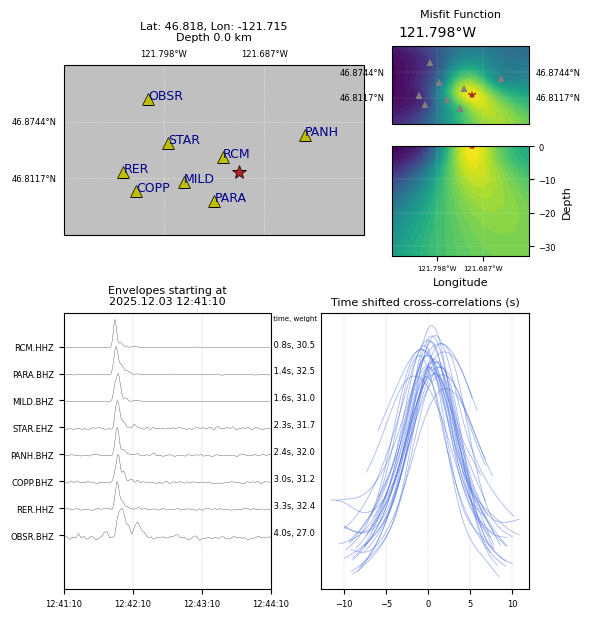

-121.71489206 46.8183377
Saved map to: ../plotly_map_locations/2025-12-03_12-41-00+00-00.html


Downloaded CC.ARAT..BHZ
Downloaded CC.CARB..BHZ
Downloaded CC.COPP..BHZ
Downloaded CC.CRBN..BHZ
Downloaded UW.FMW..HHZ
Downloaded CC.GNOB..BHZ
Downloaded UW.HTW..HHZ
Downloaded UW.LO2..EHZ
Downloaded UW.LON..HHZ
Downloaded CC.LONR..BHZ
Downloaded UW.LTY..HHZ
[PALI] no BHZ/HHZ/EHZ for C0.PALI. in window
Downloaded CC.PANH..BHZ
Downloaded CC.PR04..BHZ
Downloaded CC.PR05..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.RCS..EHZ
Downloaded UW.RER..HHZ
Downloaded CC.RUSH..BHZ
Downloaded CC.SIFT..BHZ
Downloaded CC.SUNT..HHZ
Downloaded UW.TBLMT..HHZ
Original traces: 21
Kept traces: 12
Dropped traces: 9


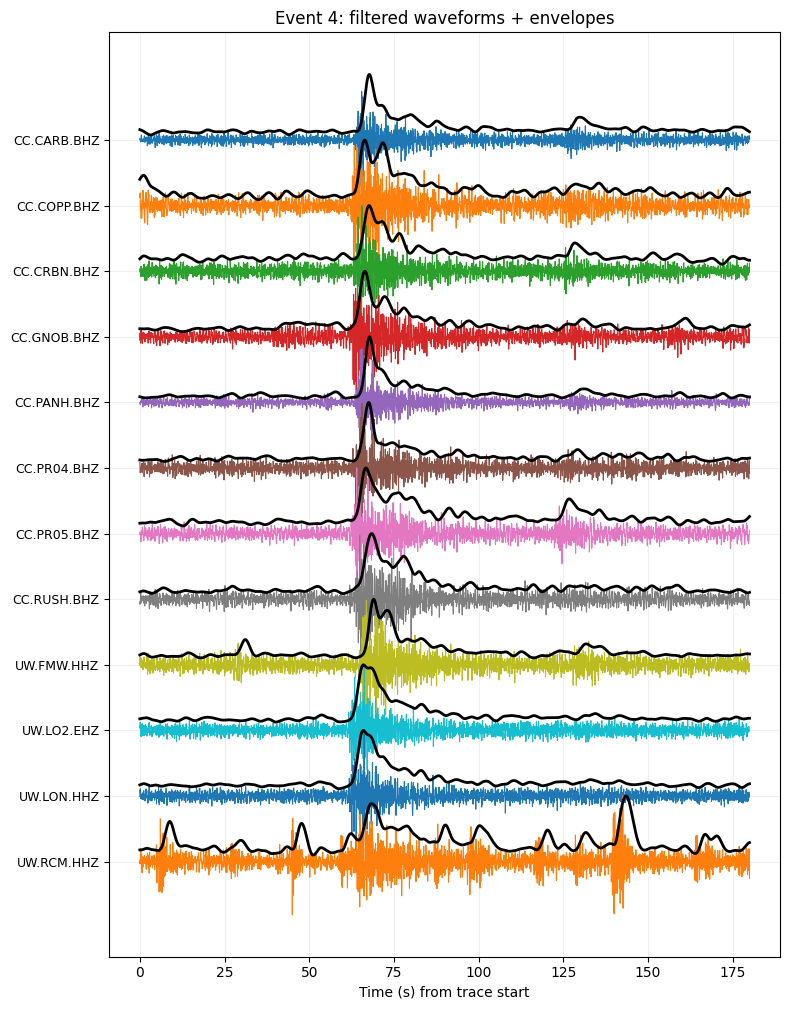

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.04 06:57:10  --  2025.12.04 07:00:10
nan nan
Saved map to: ../plotly_map_locations/2025-12-04_06-57-00+00-00.html


Downloaded CC.ARAT..BHZ
Downloaded CC.COPP..BHZ
Downloaded CC.CRYS..HHZ
Downloaded UW.FMW..HHZ
Downloaded CC.GNOB..BHZ
Downloaded UW.LON..HHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded CC.PR05..BHZ
Downloaded UW.RCM..HHZ
Downloaded CC.RUSH..BHZ
Downloaded CC.SIFT..BHZ
Downloaded CC.TABR..BHZ
Downloaded CC.TAVI..BHZ
Original traces: 16
Kept traces: 10
Dropped traces: 6


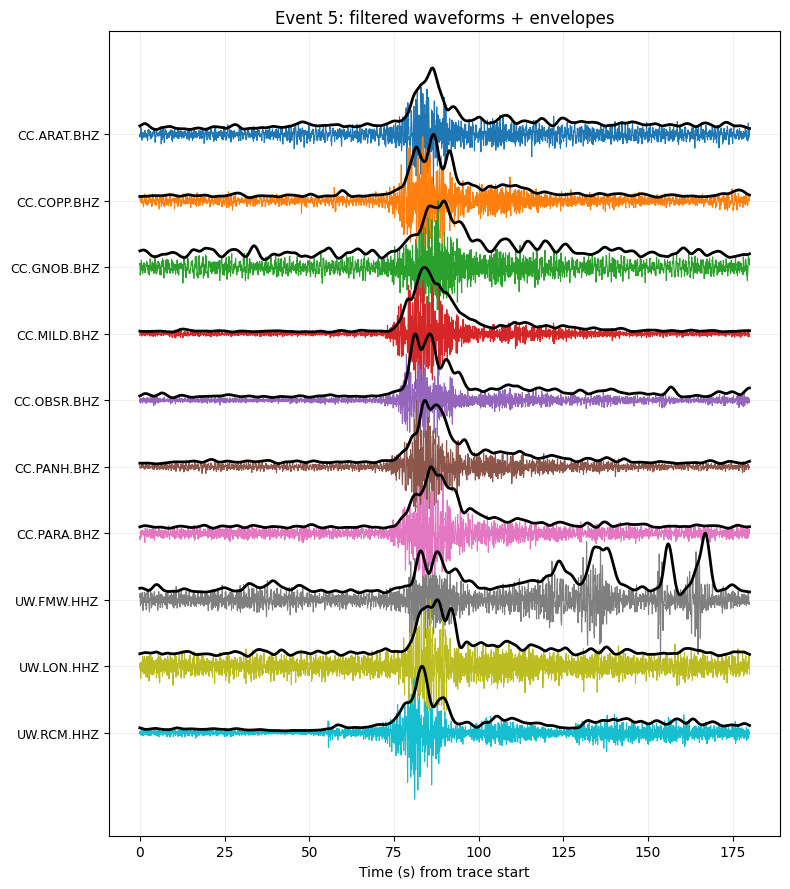

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.06 18:55:30  --  2025.12.06 18:58:30
--Location--
Latitude: 46.855, Longitude: -121.760, Depth: 0.0 km


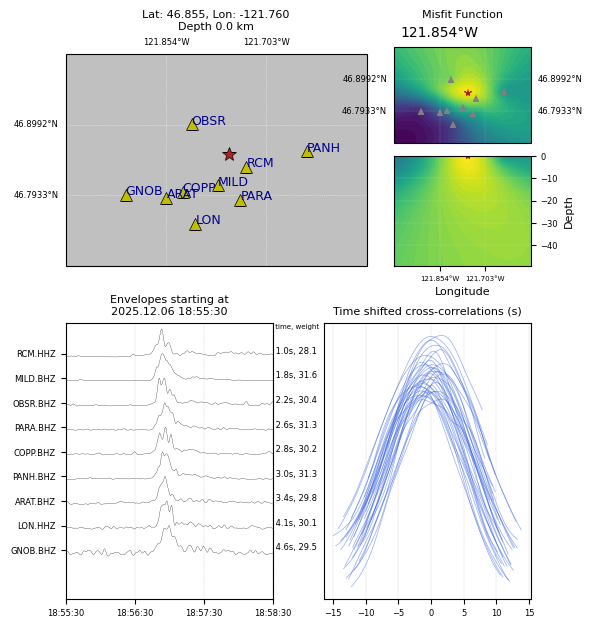

-121.75968732999999 46.85461394473684
Saved map to: ../plotly_map_locations/2025-12-06_18-55-20.002857+00-00.html


Downloaded CC.ARAT..BHZ
Downloaded CC.COPP..BHZ
Downloaded CC.GNOB..BHZ
Downloaded UW.LON..HHZ
Downloaded UW.LTY..HHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.RER..HHZ
Original traces: 11
Kept traces: 4
Dropped traces: 7


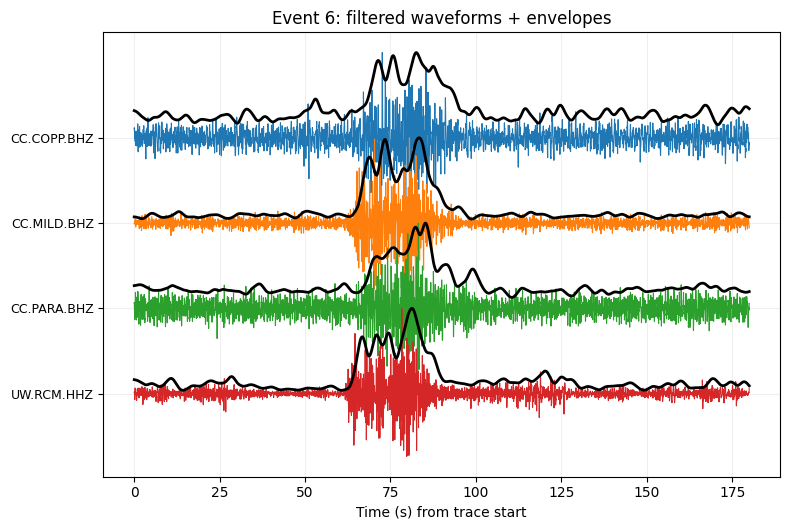

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.08 09:57:30  --  2025.12.08 10:00:30
--Location--
Latitude: 46.847, Longitude: -121.735, Depth: 0.0 km


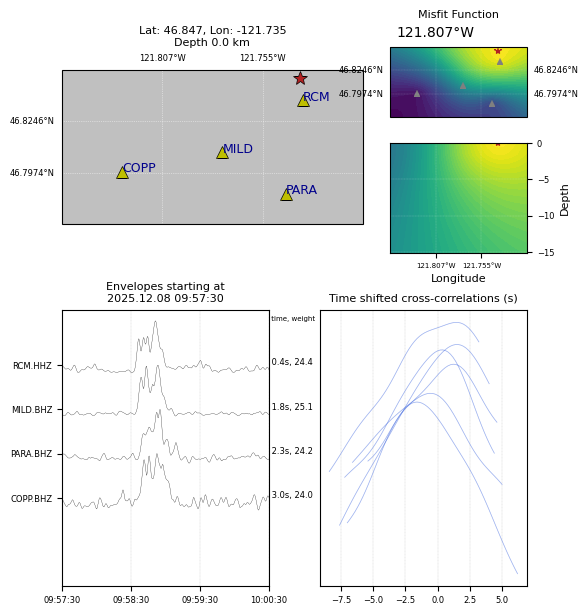

-121.73469319166668 46.847490246842106
Saved map to: ../plotly_map_locations/2025-12-08_09-57-20+00-00.html


Downloaded CC.COPP..BHZ
Downloaded CC.CRYS..HHZ
Downloaded UW.GPW..HHZ
Downloaded UW.LON..HHZ
Downloaded CC.LONR..BHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded CC.PR05..BHZ
Downloaded UW.RER..HHZ
Downloaded CC.SIFT..BHZ
Downloaded CC.SUNT..HHZ
Downloaded CC.VOIT..BHZ
Original traces: 14
Kept traces: 7
Dropped traces: 7


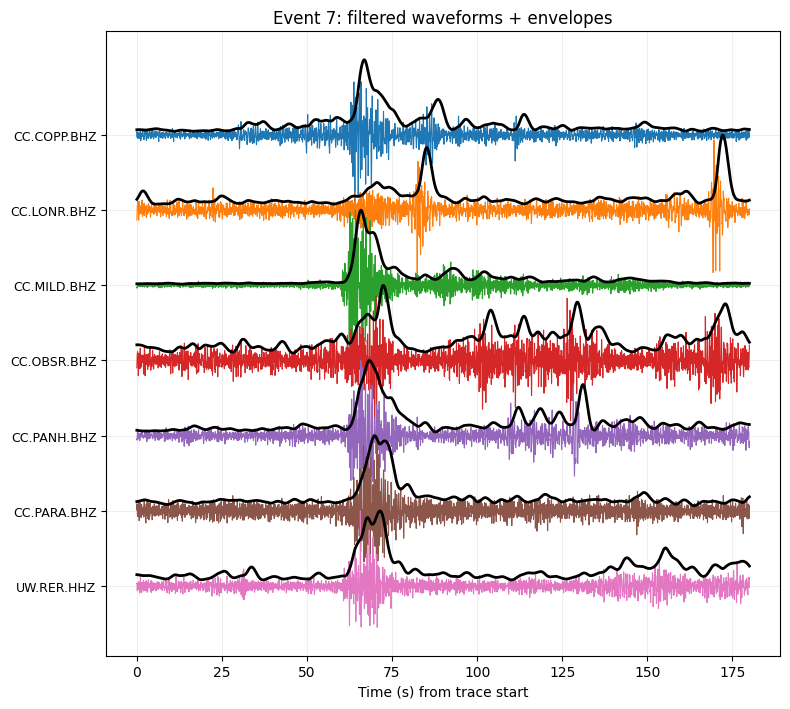

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.10 05:12:10  --  2025.12.10 05:15:10
--Location--
Latitude: 46.869, Longitude: -121.770, Depth: 0.0 km


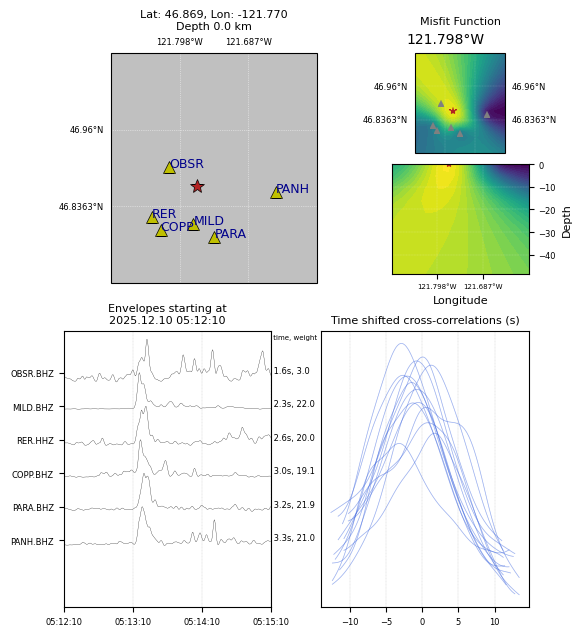

-121.77019994 46.86888192052632
Saved map to: ../plotly_map_locations/2025-12-10_05-12-00+00-00.html


Downloaded CC.COPP..BHZ
Downloaded CC.CRYS..HHZ
Downloaded UW.LO2..EHZ
Downloaded CC.LONR..BHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded CC.PR05..BHZ
Downloaded UW.RER..HHZ
Downloaded CC.RUSH..BHZ
Downloaded CC.VOIT..BHZ
Original traces: 12
Kept traces: 7
Dropped traces: 5


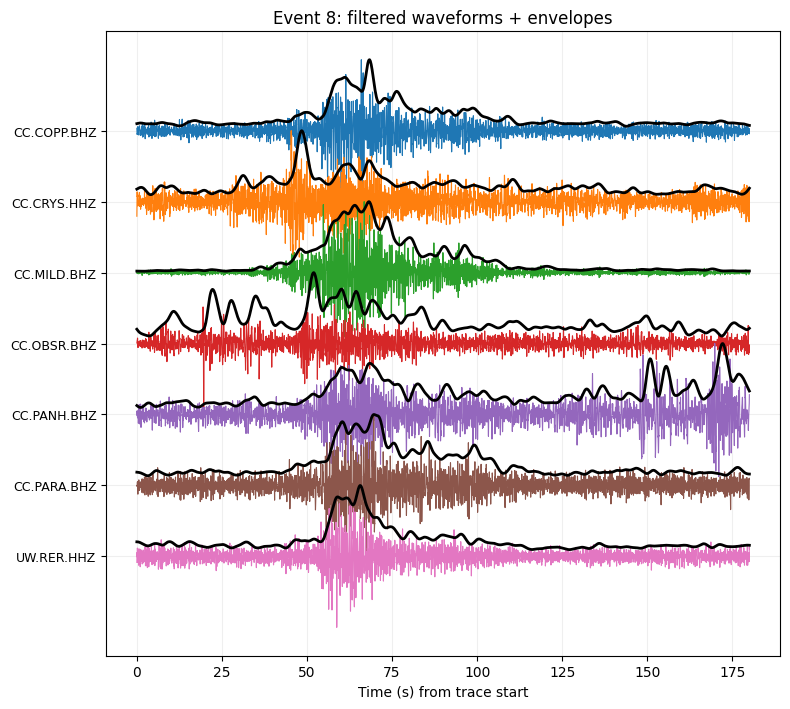

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.10 09:26:12  --  2025.12.10 09:29:12
nan nan
Saved map to: ../plotly_map_locations/2025-12-10_09-26-02.880000+00-00.html


Downloaded UW.BHW..HHZ
Downloaded CC.COPP..BHZ
Downloaded CC.GNOB..BHZ
Downloaded CC.LONR..BHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PANH..BHZ
Downloaded CC.PARA..BHZ
Downloaded CC.PR05..BHZ
Downloaded UW.RER..HHZ
Downloaded CC.SUNT..HHZ
Downloaded CC.VOIT..BHZ
Original traces: 12
Kept traces: 9
Dropped traces: 3


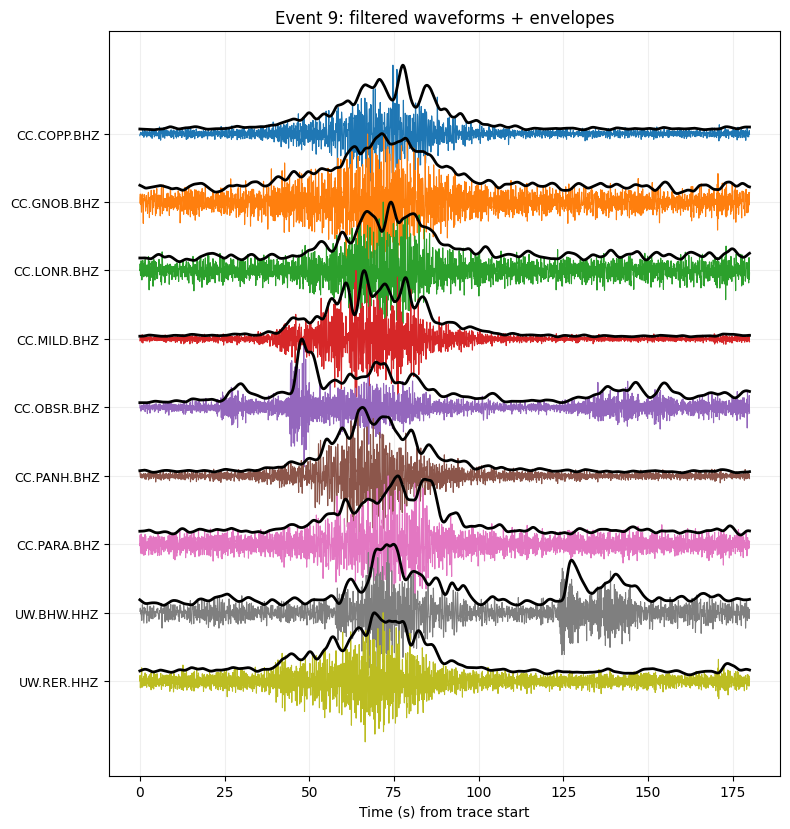

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.11 12:42:12  --  2025.12.11 12:45:12
nan nan
Saved map to: ../plotly_map_locations/2025-12-11_12-42-02.300000+00-00.html


Downloaded CC.ARAT..BHZ
Downloaded UW.BHW..HHZ
Downloaded CC.COPP..BHZ
Downloaded UW.GSM..EHZ
Downloaded UW.LON..HHZ
Downloaded CC.MILD..BHZ
Downloaded CC.OBSR..BHZ
Downloaded CC.PARA..BHZ
Downloaded UW.RCM..HHZ
Downloaded UW.RER..HHZ
Downloaded CC.VOIT..BHZ
Original traces: 11
Kept traces: 6
Dropped traces: 5


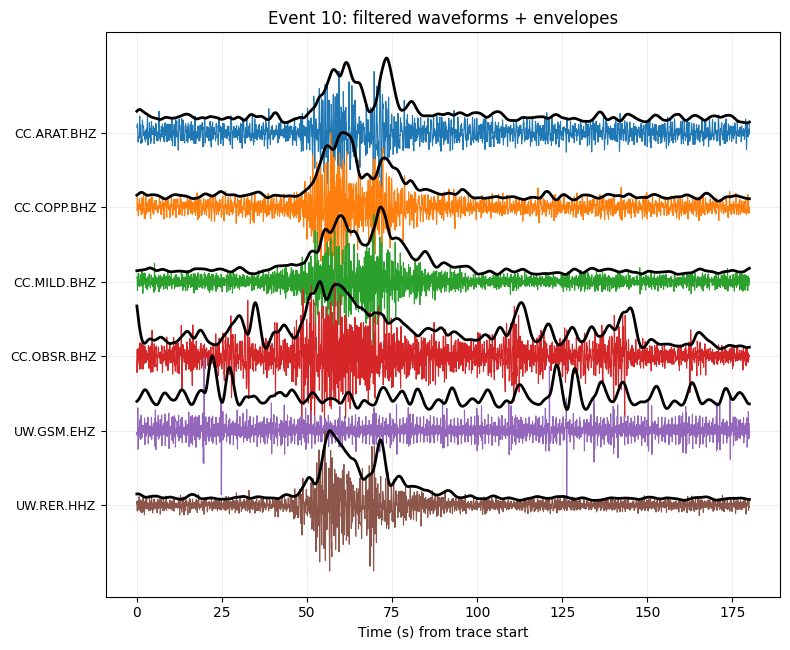

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2025.12.14 10:36:51  --  2025.12.14 10:39:51
--Location--
Latitude: 46.870, Longitude: -121.798, Depth: 0.0 km


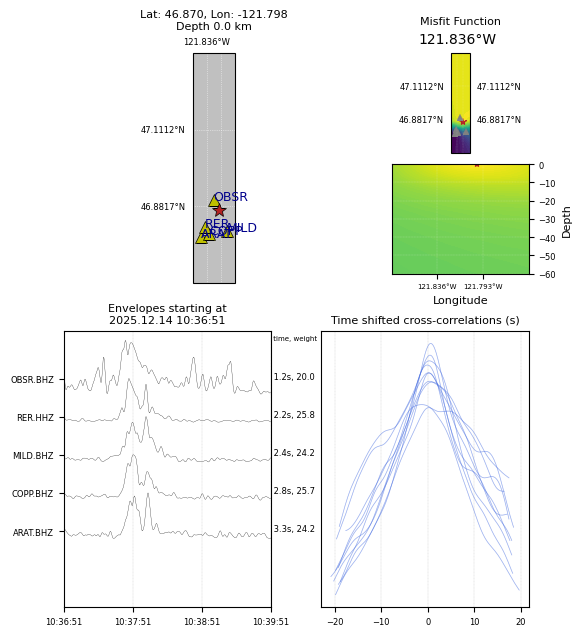

-121.79829609999999 46.8695740631579
Saved map to: ../plotly_map_locations/2025-12-14_10-36-41.240000+00-00.html


In [36]:
# Directory where maps will be saved
OUTDIR = "../plotly_map_locations"
os.makedirs(OUTDIR, exist_ok=True)


su_events = pd.read_csv('../logs/surface_event_detections_1_17_december_2025.csv')
su_events= su_events[su_events['num_stations'] > 10]
su_events = su_events.reset_index(drop=True)
su_events["enveloc_latitude"] = np.nan
su_events["enveloc_longitude"] = np.nan


# grid for pacific northwest region
mygrid = {
            "deps": np.arange( 0.1, 1, 0.5),
            "lons": np.arange(-123, -120, 0.05),
            "lats": np.arange(46, 49, 0.05)
         }


DT = 10       # seconds of padding
FREQMIN = 1.0 # minimum frequency
FREQMAX = 8.0 # maximum frequency
LOWPASS = 0.2 # lowpass for envelope smoothing



client = Client("IRIS")



for i in range(len(su_events)): 
    

        row = su_events.iloc[i]
        stream = download_station_data(row)
        
        stream = drop_stations_with_gaps(stream, max_total_gap_s=0.0)
        st = stream.copy()

        
        # filter raw waveforms
        st_raw = stream.copy()
        st_filt = st_raw.copy()

        

        st_filt.detrend("demean")
        st_filt.taper(max_percentage=None, max_length=5)
        st_filt.resample(50)
        st_filt.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=3, zerophase=True)
        st_filt, _ = filter_low_snr_traces(st_filt)

        # build envelopes from filtered waveforms (recommended: envelope AFTER bandpass)
        st_env = st_filt.copy()
        for tr in st_env:
            if tr.stats.npts % 2 == 1:
                tr.trim(tr.stats.starttime, tr.stats.endtime + 1/tr.stats.sampling_rate,
                        pad=True, fill_value=0)
            tr.data = envelope(tr.data)
            tr.resample(5.0)

        st_env.filter("lowpass", freq=LOWPASS)

        # trim both to remove taper effects (keep them comparable)
        t1 = st_filt[0].stats.starttime + DT
        t2 = st_filt[0].stats.endtime - DT
        st_filt.trim(t1, t2)
        st_env.trim(t1, t2)







        # attach coordinates to envelope traces (your existing code)

        for tr in st_env:
            inventory = client.get_stations(
                network=tr.stats.network, station=tr.stats.station,
                location=tr.stats.location, channel=tr.stats.channel,
                starttime=tr.stats.starttime, endtime=tr.stats.endtime
            )
            tr.stats.coordinates = AttribDict({
                "latitude":  inventory[0][0].latitude,
                "longitude": inventory[0][0].longitude,
                "elevation": inventory[0][0].elevation
            })

        # copy coords to filtered traces
        coords_by_id = {(tr.stats.network, tr.stats.station, tr.stats.location, tr.stats.channel): tr.stats.coordinates
                        for tr in st_env}

        for tr in st_filt:
            key = (tr.stats.network, tr.stats.station, tr.stats.location, tr.stats.channel)
            if key in coords_by_id:
                tr.stats.coordinates = coords_by_id[key]



        plot_waveforms_and_envelopes(st_filt,st_env,title=f"Event {i}: filtered waveforms + envelopes")
        
        

        env = st_env.copy()
        
        


        #XC = XCOR(env, grid_size=mygrid, plot = True,  interact= False)
        
        XC = XCOR(env, plot = True,  interact= False)
        loc = XC.locate()

       
        su_events.loc[i, "enveloc_latitude"] = loc.latitude
        su_events.loc[i, "enveloc_longitude"] = loc.longitude

        import plotly.graph_objects as go

        import plotly.io as pio
        pio.renderers.default = "notebook_connected"  # best bet for many JupyterHub setups


        # Define your region
        region = [-123, -121, 46, 48]  # [lon_min, lon_max, lat_min, lat_max]

        # Create figure
        fig = go.Figure()

        # Add the solution star (event location)
        # --- Event "star" replacement: outlined bullseye (always renders) ---
        event_lon, event_lat =  loc.longitude, loc.latitude
        
        print(event_lon, event_lat)

        # outline
        fig.add_trace(go.Scattermapbox(
            lon=[event_lon],
            lat=[event_lat],
            mode='markers',
            marker=dict(size=28, color='black'),
            name='Event (outline)',
            showlegend=False,
            hoverinfo='skip'
        ))

        # fill
        fig.add_trace(go.Scattermapbox(
            lon=[event_lon],
            lat=[event_lat],
            mode='markers',
            marker=dict(size=20, color='yellow'),
            name='Event Location',
            hovertemplate='<b>Event</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
        ))


        # Add stations (if you have station data)
        # Example station coordinates - replace with your actual data
        stations_lon = [st_env[i].stats.coordinates.longitude for i in range(len(st_env))]
        stations_lat = [st_env[i].stats.coordinates.latitude for i in range(len(st_env))]
        station_names = [st_env[i].stats.station for i in range(len(st_env))]

        fig.add_trace(go.Scattermapbox(
            lon=stations_lon,
            lat=stations_lat,
            mode='markers+text',
            marker=dict(
                size=14,
                color='red',
                symbol='triangle-up'
            ),
            marker_symbol = 'circle',
            text=station_names,
            textposition='top right',          # try: 'middle right', 'bottom right', etc.
            textfont=dict(size=12, color='black'),
            name='Stations',
            hovertemplate='<b>%{text}</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
        ))


        # Update layout with terrain basemap
        fig.update_layout(
            title='Event & Used Stations',
            mapbox=dict(
                style='stamen-terrain',  # Terrain style (free, no token needed)
                center=dict(
                    lon= event_lon,  # Center longitude
                    lat= event_lat   # Center latitude
                ),
                zoom=8.5,  # Adjust zoom level
            ),
            height=700,
            width=900,
            showlegend=True,
            legend=dict(
                x=0.98,
                y=0.98,
                xanchor='right',
                yanchor='top',
                bgcolor='rgba(255, 255, 255, 0.8)',
                bordercolor='gray',
                borderwidth=1
            )
        )

        fig.update_layout(mapbox_style="open-street-map")
        # ---- Save HTML file ----
        starttime = row["rounded_start"]  # assuming column exists

        # Convert to safe filename format (remove ":" and spaces)
        if isinstance(starttime, str):
            safe_time = starttime.replace(":", "-").replace(" ", "_")
        else:
            safe_time = str(starttime)

        filename = f"{safe_time}.html"
        filepath = os.path.join(OUTDIR, filename)

        fig.write_html(filepath)

        print(f"Saved map to: {filepath}")

        fig.show()
        



    
    


In [37]:
su_events

,Unnamed: 0,cluster_id,rounded_start,num_stations,stations,all_classes,most_common_class,mean_auc,mean_max,mean_prob,enveloc_latitude,enveloc_longitude
0,105,432,2025-12-01 07:57:40+00:00,11,"['ARAT', 'COPP', 'LO2', 'MILD', 'OBSR', 'PANH'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.456046,0.793113,0.479240,46.857925,-121.742546
1,345,1278,2025-12-01 23:17:20+00:00,19,"['ARAT', 'COPP', 'FMW', 'LO2', 'LON', 'LONR', ...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,6.819350,0.815300,0.502831,46.868918,-121.734406
2,547,2116,2025-12-02 13:24:30+00:00,12,"['BHW', 'COPP', 'FMW', 'GPW', 'JCW', 'LON', 'M...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,15.450455,0.798916,0.514053,46.812366,-121.722262
3,844,3482,2025-12-03 12:41:00+00:00,12,"['ARAT', 'COPP', 'FMW', 'LO2', 'LON', 'MILD', ...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,5.597377,0.761653,0.468448,46.818338,-121.714892
4,1103,4572,2025-12-04 06:57:00+00:00,22,"['ARAT', 'CARB', 'COPP', 'CRBN', 'FMW', 'GNOB'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.624186,0.763904,0.429611,NaN,NaN
5,1870,8262,2025-12-06 18:55:20.002857+00:00,16,"['ARAT', 'COPP', 'CRYS', 'FMW', 'GNOB', 'LON',...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.871611,0.877268,0.553660,46.854614,-121.759687
6,2232,10611,2025-12-08 09:57:20+00:00,11,"['ARAT', 'COPP', 'GNOB', 'LON', 'LTY', 'MILD',...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,8.004866,0.885728,0.554033,46.847490,-121.734693
7,2650,13213,2025-12-10 05:12:00+00:00,14,"['COPP', 'CRYS', 'GPW', 'LON', 'LONR', 'MILD',...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.516970,0.751089,0.442377,46.868882,-121.770200
8,2694,13469,2025-12-10 09:26:02.880000+00:00,12,"['COPP', 'CRYS', 'LO2', 'LONR', 'MILD', 'OBSR'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,7.514473,0.803965,0.495088,NaN,NaN
9,2891,15124,2025-12-11 12:42:02.300000+00:00,12,"['BHW', 'COPP', 'GNOB', 'LONR', 'MILD', 'OBSR'...","['su', 'su', 'su', 'su', 'su', 'su', 'su', 'su...",su,9.901246,0.925788,0.610464,NaN,NaN


In [38]:
su_events = su_events.dropna()
su_events.to_csv('../src/surface_events_10_stations_dec_2025.csv')

## Saving as QuakeML format

In [46]:
import pandas as pd
import ast
from obspy import UTCDateTime
from obspy.core.event import (
    Catalog, Event, Origin, Comment,
    CreationInfo, ResourceIdentifier
)


df = su_events.copy()

# Drop junk index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Parse times safely
df["rounded_start"] = pd.to_datetime(df["rounded_start"], utc=True, errors="coerce")

catalog = Catalog()
catalog.description = "Surface-event detections converted from CSV"
catalog.creation_info = CreationInfo(author="Akash", agency_id="UW/PNSN")

for _, row in df.iterrows():
    # Skip rows with bad times
    if pd.isna(row["rounded_start"]):
        continue

    event = Event()
    event.resource_id = ResourceIdentifier(f"smi:local/event/{row['cluster_id']}")

    origin = Origin()
    origin.resource_id = ResourceIdentifier(f"smi:local/origin/{row['cluster_id']}")

    # Convert pandas Timestamp -> python datetime -> UTCDateTime
    origin.time = UTCDateTime(row["rounded_start"].to_pydatetime())

    lat = row.get("enveloc_latitude", None)
    lon = row.get("enveloc_longitude", None)

    if pd.notna(lat) and pd.notna(lon):
        origin.latitude = float(lat)
        origin.longitude = float(lon)

    event.origins.append(origin)
    event.preferred_origin_id = origin.resource_id

    metadata_fields = [
        "cluster_id", "num_stations", "stations", "all_classes",
        "most_common_class", "mean_auc", "mean_max", "mean_prob"
    ]

    for field in metadata_fields:
        if field in row and pd.notna(row[field]):
            value = row[field]

            if field in ["stations", "all_classes"] and isinstance(value, str):
                try:
                    value = ast.literal_eval(value)
                except Exception:
                    pass

            event.comments.append(Comment(text=f"{field}: {value}"))

    catalog.events.append(event)

output_file = "../src/surface_events.xml"
catalog.write(output_file, format="QUAKEML")
print(f"Saved QuakeML catalog to: {output_file}")

Saved QuakeML catalog to: ../src/surface_events.xml


'2025-12-01 07:57:40+00:00'